# PARTE 2 — Benchmark de Ingesta: PostgreSQL Relacional vs MongoDB

Comparamos el costo de cargar el **mismo universo de hechos** generado en PARTE 1 en dos motores con modelos de datos distintos:

| # | Motor                          | Modelo de datos        | Cliente Python |
|---|--------------------------------|------------------------|----------------|
| 1 | **PostgreSQL — Relacional**    | 13 tablas normalizadas | `psycopg2`     |
| 2 | **MongoDB**                    | Documental jerárquico  | `pymongo`      |

## Universo comparado (salida de PARTE 1)
- **731 días** (2023-01-01 → 2024-12-31, cobertura 100%).
- **4,376 vuelos** · **263,008 boletos** · **9,978 filas de tripulación**.
- En relacional: las 13 tablas normalizadas.
- En documental: los **731 documentos jerárquicos** (un doc/día, mismos hechos embebidos hasta profundidad 7).

## Decisión de granularidad
Cada motor ingiere el universo en su **forma natural**:
- SQL inserta filas normalizadas (~263k boletos + relaciones + tripulación).
- MongoDB inserta los 731 documentos jerárquicos que **ya contienen** esos mismos hechos embebidos.

No se aplana el JSON a 263k docs planos porque eso desperdicia el modelo embebido de Mongo y rompe la coherencia con PARTE 3 (BigQuery RECORD/REPEATED) y PARTE 4 (Neo4j). El reporte final reportará explícitamente "263k filas SQL vs 731 docs Mongo, mismo contenido".

## Protocolo de medición
- Cronómetro: `time.perf_counter()` rodeando **solo** la llamada al motor (`execute_values` + `commit` en SQL; `insert_many` en Mongo).
- **3 corridas** por motor, se reporta la **mediana**.
- **Reset de BD entre corridas**: DROP+CREATE en SQL, `drop_database` en Mongo (evita cache caliente).
- Adicionalmente: 3 corridas por motor **por año** (2023 / 2024) para el reporte final partido.

## Pre-requisitos
- PostgreSQL ya cargado por PARTE 1 (`gestionaeropuerto`).
- MongoDB local en `mongodb://localhost:27017`.
- JSON jerárquico exportado en `salida_json/aeropuerto_jerarquico.json`.


## 1. Configuración

In [1]:
import os, json, time, statistics
from datetime import datetime
import psycopg2
from psycopg2.extras import execute_values
from pymongo import MongoClient

PG_CONFIG = {'host': 'localhost', 'port': 5432, 'user': 'jesusrodarte'}
PG_DB_REL       = 'gestionaeropuerto'           # fuente — generada en PARTE 1
PG_DB_TEST_REL  = 'gestionaeropuerto_test_rel'  # destino — se recrea cada corrida

MONGO_URI  = 'mongodb://localhost:27017'
MONGO_DB   = 'gestionaeropuerto_test'
MONGO_COLL = 'vuelos_diarios'

JSON_PATH = 'parte1/aeropuerto_jerarquico.json'
OUTDIR    = 'parte2'
REPETICIONES = 3

os.makedirs(OUTDIR, exist_ok=True)
print('Config OK')

Config OK


In [2]:
# Validación del dataset canónico contra el manifest de P1
import hashlib

MANIFEST_PATH = 'parte1/dataset_manifest.json'

with open(MANIFEST_PATH, encoding='utf-8') as f:
    manifest = json.load(f)

_h = hashlib.sha256()
with open(JSON_PATH, 'rb') as f:
    for chunk in iter(lambda: f.read(1024 * 1024), b''):
        _h.update(chunk)
sha_actual = _h.hexdigest()

assert sha_actual == manifest['sha256'], (
    f"DATASET CAMBIÓ — re-ejecutar PARTE 1\n"
    f"  esperado:  {manifest['sha256']}\n"
    f"  actual:    {sha_actual}"
)
print(f"Dataset canónico verificado: {sha_actual[:16]}... ({manifest['n_documentos']} docs)")

Dataset canónico verificado: 454163d8e4c2276f... (731 docs)


## 2. Cargar dataset común

Se extrae **una sola vez** todo lo necesario:
- Filas tabulares desde la BD relacional original (para reinyectar en el benchmark SQL).
- Documentos jerárquicos desde el JSON (para Mongo).

La extracción **no está cronometrada** — solo lo que pasa entre `t0` y `t1` cuenta.

In [3]:
# --- 2.1 JSON jerárquico (731 docs) ---
with open(JSON_PATH, encoding='utf-8') as f:
    documentos_json = json.load(f)

# Particiones por año para el análisis 2023 vs 2024
docs_2023 = [d for d in documentos_json if d['fecha'].startswith('2023')]
docs_2024 = [d for d in documentos_json if d['fecha'].startswith('2024')]

print(f'JSON: {len(documentos_json)} docs  |  2023={len(docs_2023)}  2024={len(docs_2024)}')

# --- 2.2 Filas tabulares desde PG ---
conn = psycopg2.connect(dbname=PG_DB_REL, **PG_CONFIG); cur = conn.cursor()

cur.execute('SELECT * FROM Aerolineas');            rows_aerolineas = cur.fetchall()
cur.execute('SELECT * FROM Aeropuertos');           rows_aeropuertos = cur.fetchall()
cur.execute('SELECT * FROM Modelos_Avion');         rows_modelos = cur.fetchall()
cur.execute('SELECT * FROM Servicios_Adicionales'); rows_servicios = cur.fetchall()
cur.execute('SELECT * FROM Empleados');             rows_empleados = cur.fetchall()
cur.execute('SELECT * FROM Pasajeros');             rows_pasajeros = cur.fetchall()
cur.execute('SELECT * FROM Aerolinea_Aeropuertos'); rows_ae_ap = cur.fetchall()
cur.execute('SELECT * FROM Vuelos ORDER BY Fecha_Hora_Salida'); rows_vuelos = cur.fetchall()
cur.execute('SELECT * FROM Reservas');              rows_reservas = cur.fetchall()
cur.execute('SELECT * FROM Pasajeros_Reserva');     rows_pas_res = cur.fetchall()
cur.execute('SELECT * FROM Servicios_Reserva');     rows_serv_res = cur.fetchall()
cur.execute('SELECT * FROM Boletos');               rows_boletos = cur.fetchall()
cur.execute('SELECT * FROM Tripulacion_Vuelo');     rows_tripulacion = cur.fetchall()

cur.close(); conn.close()

# --- 2.3 Particionar filas tabulares por año (usando Fecha_Hora_Salida del vuelo) ---
# Mapas vuelo→año, reserva→año, etc., para filtrar todo lo derivado.
vuelo_anio = {v[0]: v[5].year for v in rows_vuelos}  # ID_Vuelo_Operacion -> año

def split_by_year(rows, year_of_row):
    a, b = [], []
    for r in rows:
        y = year_of_row(r)
        if y == 2023: a.append(r)
        elif y == 2024: b.append(r)
    return a, b

# Reservas: índice 1 es ID_Vuelo_Operacion
reservas_2023, reservas_2024 = split_by_year(rows_reservas, lambda r: vuelo_anio.get(r[1]))
pnr_2023 = {r[0] for r in reservas_2023}
pnr_2024 = {r[0] for r in reservas_2024}

vuelos_2023 = [v for v in rows_vuelos if v[5].year == 2023]
vuelos_2024 = [v for v in rows_vuelos if v[5].year == 2024]
boletos_2023 = [b for b in rows_boletos if b[1] in pnr_2023]
boletos_2024 = [b for b in rows_boletos if b[1] in pnr_2024]
pas_res_2023 = [p for p in rows_pas_res if p[0] in pnr_2023]
pas_res_2024 = [p for p in rows_pas_res if p[0] in pnr_2024]
serv_res_2023 = [s for s in rows_serv_res if s[0] in pnr_2023]
serv_res_2024 = [s for s in rows_serv_res if s[0] in pnr_2024]
tripulacion_2023 = [t for t in rows_tripulacion if vuelo_anio.get(t[0]) == 2023]
tripulacion_2024 = [t for t in rows_tripulacion if vuelo_anio.get(t[0]) == 2024]

print(f'Tabular total: vuelos={len(rows_vuelos):,}  boletos={len(rows_boletos):,}  tripulacion={len(rows_tripulacion):,}')
print(f'  2023: vuelos={len(vuelos_2023):,}  boletos={len(boletos_2023):,}  tripulacion={len(tripulacion_2023):,}')
print(f'  2024: vuelos={len(vuelos_2024):,}  boletos={len(boletos_2024):,}  tripulacion={len(tripulacion_2024):,}')

JSON: 731 docs  |  2023=365  2024=366
Tabular total: vuelos=4,376  boletos=263,008  tripulacion=9,978
  2023: vuelos=2,175  boletos=131,412  tripulacion=4,983
  2024: vuelos=2,201  boletos=131,596  tripulacion=4,995


## 3. Motor 1 — PostgreSQL Relacional

DDL con **las 13 tablas** de PARTE 1 (incluyendo `Tripulacion_Vuelo`). Se cronometra el bloque de INSERTs + `commit`.

In [4]:
DDL_REL = """
CREATE TABLE Aerolineas (
    Codigo_IATA_Aerolinea CHAR(2) PRIMARY KEY,
    Nombre_Comercial      VARCHAR(100) NOT NULL,
    Pais_Origen           VARCHAR(50)  NOT NULL
);
CREATE TABLE Aeropuertos (
    Codigo_IATA_Aeropuerto CHAR(3) PRIMARY KEY,
    Nombre_Oficial         VARCHAR(150) NOT NULL,
    Ciudad                 VARCHAR(100) NOT NULL,
    Pais                   VARCHAR(50)  NOT NULL
);
CREATE TABLE Modelos_Avion (
    Codigo_Modelo       VARCHAR(15) PRIMARY KEY,
    Fabricante          VARCHAR(50) NOT NULL,
    Capacidad_Pasajeros INT         NOT NULL,
    Alcance_Km          INT
);
CREATE TABLE Empleados (
    Numero_Licencia       VARCHAR(20) PRIMARY KEY,
    Codigo_IATA_Aerolinea CHAR(2)     NOT NULL REFERENCES Aerolineas(Codigo_IATA_Aerolinea) ON DELETE CASCADE,
    Nombre_Completo       VARCHAR(150) NOT NULL,
    Rol                   VARCHAR(50)  NOT NULL
);
CREATE TABLE Pasajeros (
    Numero_Pasaporte VARCHAR(20) PRIMARY KEY,
    Nombre_Completo  VARCHAR(150) NOT NULL,
    Fecha_Nacimiento DATE         NOT NULL,
    Nacionalidad     VARCHAR(50)  NOT NULL
);
CREATE TABLE Servicios_Adicionales (
    Codigo_Servicio VARCHAR(10)  PRIMARY KEY,
    Descripcion     VARCHAR(150) NOT NULL,
    Precio_Base     NUMERIC(10,2) NOT NULL
);
CREATE TABLE Aerolinea_Aeropuertos (
    Codigo_IATA_Aerolinea  CHAR(2) NOT NULL REFERENCES Aerolineas(Codigo_IATA_Aerolinea)  ON DELETE CASCADE,
    Codigo_IATA_Aeropuerto CHAR(3) NOT NULL REFERENCES Aeropuertos(Codigo_IATA_Aeropuerto) ON DELETE CASCADE,
    Es_Hub_Principal       BOOLEAN NOT NULL,
    Terminal_Asignada      VARCHAR(10),
    PRIMARY KEY (Codigo_IATA_Aerolinea, Codigo_IATA_Aeropuerto)
);
CREATE TABLE Vuelos (
    ID_Vuelo_Operacion    VARCHAR(20) PRIMARY KEY,
    Codigo_IATA_Aerolinea CHAR(2)     NOT NULL REFERENCES Aerolineas(Codigo_IATA_Aerolinea),
    Origen_IATA           CHAR(3)     NOT NULL REFERENCES Aeropuertos(Codigo_IATA_Aeropuerto),
    Destino_IATA          CHAR(3)     NOT NULL REFERENCES Aeropuertos(Codigo_IATA_Aeropuerto),
    Codigo_Modelo         VARCHAR(15) NOT NULL REFERENCES Modelos_Avion(Codigo_Modelo),
    Fecha_Hora_Salida     TIMESTAMP   NOT NULL,
    Fecha_Hora_Llegada    TIMESTAMP   NOT NULL,
    Estado_Vuelo          VARCHAR(20) NOT NULL
);
CREATE TABLE Reservas (
    PNR_Localizador     CHAR(6)     PRIMARY KEY,
    ID_Vuelo_Operacion  VARCHAR(20) NOT NULL REFERENCES Vuelos(ID_Vuelo_Operacion) ON DELETE CASCADE,
    Fecha_Emision       TIMESTAMP   NOT NULL,
    Estado_Pago         VARCHAR(20) NOT NULL,
    Monto_Total         NUMERIC(10,2) NOT NULL
);
CREATE TABLE Pasajeros_Reserva (
    PNR_Localizador  CHAR(6)     NOT NULL REFERENCES Reservas(PNR_Localizador)   ON DELETE CASCADE,
    Numero_Pasaporte VARCHAR(20) NOT NULL REFERENCES Pasajeros(Numero_Pasaporte) ON DELETE CASCADE,
    Asiento_Asignado VARCHAR(5),
    Clase_Tarifa     VARCHAR(30) NOT NULL,
    PRIMARY KEY (PNR_Localizador, Numero_Pasaporte)
);
CREATE TABLE Servicios_Reserva (
    PNR_Localizador      CHAR(6)     NOT NULL REFERENCES Reservas(PNR_Localizador)              ON DELETE CASCADE,
    Codigo_Servicio      VARCHAR(10) NOT NULL REFERENCES Servicios_Adicionales(Codigo_Servicio) ON DELETE CASCADE,
    Cantidad             INT         NOT NULL,
    Costo_Final_Aplicado NUMERIC(10,2) NOT NULL,
    PRIMARY KEY (PNR_Localizador, Codigo_Servicio)
);
CREATE TABLE Boletos (
    Numero_Boleto       VARCHAR(13) PRIMARY KEY,
    PNR_Localizador     CHAR(6)     NOT NULL REFERENCES Reservas(PNR_Localizador) ON DELETE CASCADE,
    Numero_Pasaporte    VARCHAR(20) NOT NULL REFERENCES Pasajeros(Numero_Pasaporte),
    ID_Vuelo_Operacion  VARCHAR(20) NOT NULL REFERENCES Vuelos(ID_Vuelo_Operacion),
    Fecha_Emision       TIMESTAMP   NOT NULL,
    Asiento_Asignado    VARCHAR(5),
    Clase_Tarifa        VARCHAR(30) NOT NULL,
    Estado_Boleto       VARCHAR(20) NOT NULL
);
CREATE TABLE Tripulacion_Vuelo (
    ID_Vuelo_Operacion VARCHAR(20) NOT NULL REFERENCES Vuelos(ID_Vuelo_Operacion) ON DELETE CASCADE,
    Numero_Licencia    VARCHAR(20) NOT NULL REFERENCES Empleados(Numero_Licencia) ON DELETE CASCADE,
    Rol_En_Vuelo       VARCHAR(50) NOT NULL,
    PRIMARY KEY (ID_Vuelo_Operacion, Numero_Licencia)
);
"""

def reset_pg(db_name, ddl):
    adm = psycopg2.connect(dbname='postgres', **PG_CONFIG)
    adm.autocommit = True
    c = adm.cursor()
    c.execute("""
        SELECT pg_terminate_backend(pid) FROM pg_stat_activity
        WHERE datname = %s AND pid <> pg_backend_pid();
    """, (db_name,))
    c.execute(f"DROP DATABASE IF EXISTS {db_name};")
    c.execute(f"CREATE DATABASE {db_name};")
    c.close(); adm.close()
    if ddl:
        cn = psycopg2.connect(dbname=db_name, **PG_CONFIG); cn.autocommit = False
        cu = cn.cursor(); cu.execute(ddl); cn.commit()
        cu.close(); cn.close()

def ingesta_pg_relacional(vuelos, reservas, pas_res, serv_res, boletos, tripulacion):
    """Inserta el subconjunto pedido + todos los catálogos. Devuelve segundos."""
    cn = psycopg2.connect(dbname=PG_DB_TEST_REL, **PG_CONFIG)
    cn.autocommit = False; cu = cn.cursor()

    t0 = time.perf_counter()
    execute_values(cu, "INSERT INTO Aerolineas VALUES %s",            rows_aerolineas,  page_size=500)
    execute_values(cu, "INSERT INTO Aeropuertos VALUES %s",           rows_aeropuertos, page_size=500)
    execute_values(cu, "INSERT INTO Modelos_Avion VALUES %s",         rows_modelos,     page_size=500)
    execute_values(cu, "INSERT INTO Servicios_Adicionales VALUES %s", rows_servicios,   page_size=500)
    execute_values(cu, "INSERT INTO Empleados VALUES %s",             rows_empleados,   page_size=500)
    execute_values(cu, "INSERT INTO Pasajeros VALUES %s",             rows_pasajeros,   page_size=1000)
    execute_values(cu, "INSERT INTO Aerolinea_Aeropuertos VALUES %s", rows_ae_ap,       page_size=500)
    execute_values(cu, "INSERT INTO Vuelos VALUES %s",                vuelos,           page_size=1000)
    execute_values(cu, "INSERT INTO Reservas VALUES %s",              reservas,         page_size=1000)
    execute_values(cu, "INSERT INTO Pasajeros_Reserva VALUES %s",     pas_res,          page_size=2000)
    execute_values(cu, "INSERT INTO Servicios_Reserva VALUES %s",     serv_res,         page_size=1000)
    execute_values(cu, "INSERT INTO Boletos VALUES %s",               boletos,          page_size=2000)
    execute_values(cu, "INSERT INTO Tripulacion_Vuelo VALUES %s",     tripulacion,      page_size=1000)
    cn.commit()
    t1 = time.perf_counter()

    cu.close(); cn.close()
    return t1 - t0

def benchmark_pg(vuelos, reservas, pas_res, serv_res, boletos, tripulacion, etiqueta):
    tiempos = []
    for i in range(REPETICIONES):
        reset_pg(PG_DB_TEST_REL, DDL_REL)
        t = ingesta_pg_relacional(vuelos, reservas, pas_res, serv_res, boletos, tripulacion)
        tiempos.append(t)
        print(f'  [{etiqueta}] run {i+1}: {t:.3f}s')
    return tiempos

# Corrida GLOBAL (todo el universo PARTE 1)
print('PG-Relacional · GLOBAL')
tiempos_pg_global = benchmark_pg(rows_vuelos, rows_reservas, rows_pas_res, rows_serv_res,
                                  rows_boletos, rows_tripulacion, 'global')
print(f'  mediana: {statistics.median(tiempos_pg_global):.3f}s\n')

# Corridas por año
print('PG-Relacional · 2023')
tiempos_pg_2023 = benchmark_pg(vuelos_2023, reservas_2023, pas_res_2023, serv_res_2023,
                                boletos_2023, tripulacion_2023, '2023')
print(f'  mediana: {statistics.median(tiempos_pg_2023):.3f}s\n')

print('PG-Relacional · 2024')
tiempos_pg_2024 = benchmark_pg(vuelos_2024, reservas_2024, pas_res_2024, serv_res_2024,
                                boletos_2024, tripulacion_2024, '2024')
print(f'  mediana: {statistics.median(tiempos_pg_2024):.3f}s')

PG-Relacional · GLOBAL
  [global] run 1: 8.306s
  [global] run 2: 8.647s
  [global] run 3: 8.683s
  mediana: 8.647s

PG-Relacional · 2023
  [2023] run 1: 4.283s
  [2023] run 2: 4.292s
  [2023] run 3: 4.263s
  mediana: 4.283s

PG-Relacional · 2024
  [2024] run 1: 4.309s
  [2024] run 2: 4.294s
  [2024] run 3: 4.326s
  mediana: 4.309s


## 4. Motor 2 — MongoDB

`insert_many(ordered=False)` sobre la colección. La BD se dropea entre corridas.

In [5]:
def reset_mongo():
    cli = MongoClient(MONGO_URI)
    cli.drop_database(MONGO_DB)
    cli.close()

def ingesta_mongo(docs):
    cli = MongoClient(MONGO_URI)
    coll = cli[MONGO_DB][MONGO_COLL]
    payload = [dict(d) for d in docs]  # copia para no contaminar con _id

    t0 = time.perf_counter()
    res = coll.insert_many(payload, ordered=False)
    n = len(res.inserted_ids)
    t1 = time.perf_counter()

    cli.close()
    return t1 - t0, n

def benchmark_mongo(docs, etiqueta):
    tiempos = []
    for i in range(REPETICIONES):
        reset_mongo()
        t, n = ingesta_mongo(docs)
        tiempos.append(t)
        print(f'  [{etiqueta}] run {i+1}: {t:.3f}s (docs={n})')
    return tiempos

print('Mongo · GLOBAL')
tiempos_mongo_global = benchmark_mongo(documentos_json, 'global')
print(f'  mediana: {statistics.median(tiempos_mongo_global):.3f}s\n')

print('Mongo · 2023')
tiempos_mongo_2023 = benchmark_mongo(docs_2023, '2023')
print(f'  mediana: {statistics.median(tiempos_mongo_2023):.3f}s\n')

print('Mongo · 2024')
tiempos_mongo_2024 = benchmark_mongo(docs_2024, '2024')
print(f'  mediana: {statistics.median(tiempos_mongo_2024):.3f}s')

# Limpieza final
reset_mongo()

Mongo · GLOBAL
  [global] run 1: 0.424s (docs=731)
  [global] run 2: 0.368s (docs=731)
  [global] run 3: 0.368s (docs=731)
  mediana: 0.368s

Mongo · 2023
  [2023] run 1: 0.199s (docs=365)
  [2023] run 2: 0.201s (docs=365)
  [2023] run 3: 0.216s (docs=365)
  mediana: 0.201s

Mongo · 2024
  [2024] run 1: 0.194s (docs=366)
  [2024] run 2: 0.207s (docs=366)
  [2024] run 3: 0.203s (docs=366)
  mediana: 0.203s


## 5. Resultados consolidados

In [6]:
import pandas as pd

def fila(motor, alcance, tiempos, n_unidades, unidad):
    return {
        'Motor':      motor,
        'Alcance':    alcance,
        'Unidades':   f'{n_unidades:,} {unidad}',
        'Run 1 (s)':  round(tiempos[0], 3),
        'Run 2 (s)':  round(tiempos[1], 3),
        'Run 3 (s)':  round(tiempos[2], 3),
        'Mediana (s)': round(statistics.median(tiempos), 3),
        'Mín (s)':    round(min(tiempos), 3),
        'Máx (s)':    round(max(tiempos), 3),
    }

n_sql_global = len(rows_vuelos)+len(rows_reservas)+len(rows_pas_res)+len(rows_serv_res)+len(rows_boletos)+len(rows_tripulacion)
n_sql_2023   = len(vuelos_2023)+len(reservas_2023)+len(pas_res_2023)+len(serv_res_2023)+len(boletos_2023)+len(tripulacion_2023)
n_sql_2024   = len(vuelos_2024)+len(reservas_2024)+len(pas_res_2024)+len(serv_res_2024)+len(boletos_2024)+len(tripulacion_2024)

resumen = pd.DataFrame([
    fila('PostgreSQL Relacional', 'Global',   tiempos_pg_global,    n_sql_global, 'filas'),
    fila('MongoDB',               'Global',   tiempos_mongo_global, len(documentos_json), 'docs'),
    fila('PostgreSQL Relacional', '2023',     tiempos_pg_2023,      n_sql_2023, 'filas'),
    fila('MongoDB',               '2023',     tiempos_mongo_2023,   len(docs_2023), 'docs'),
    fila('PostgreSQL Relacional', '2024',     tiempos_pg_2024,      n_sql_2024, 'filas'),
    fila('MongoDB',               '2024',     tiempos_mongo_2024,   len(docs_2024), 'docs'),
])
resumen

,Motor,Alcance,Unidades,Run 1 (s),Run 2 (s),Run 3 (s),Mediana (s),Mín (s),Máx (s)
0,PostgreSQL Relacional,Global,"543,918 filas",8.306,8.647,8.683,8.647,8.306,8.683
1,MongoDB,Global,731 docs,0.424,0.368,0.368,0.368,0.368,0.424
2,PostgreSQL Relacional,2023,"271,689 filas",4.283,4.292,4.263,4.283,4.263,4.292
3,MongoDB,2023,365 docs,0.199,0.201,0.216,0.201,0.199,0.216
4,PostgreSQL Relacional,2024,"272,229 filas",4.309,4.294,4.326,4.309,4.294,4.326
5,MongoDB,2024,366 docs,0.194,0.207,0.203,0.203,0.194,0.207


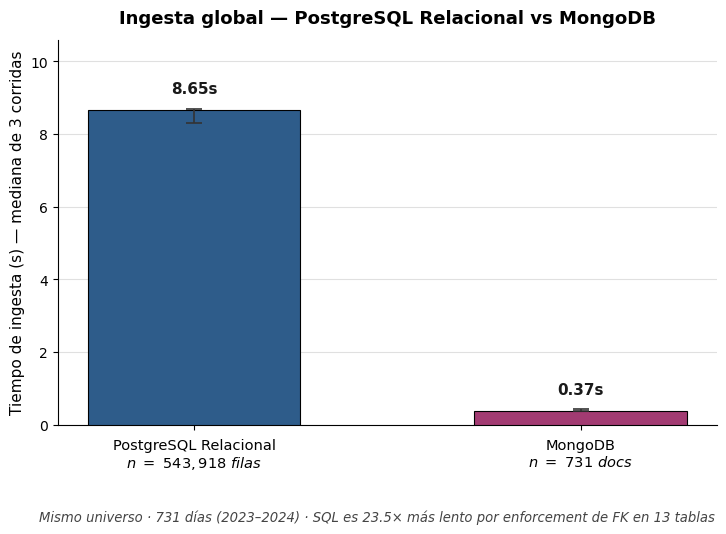

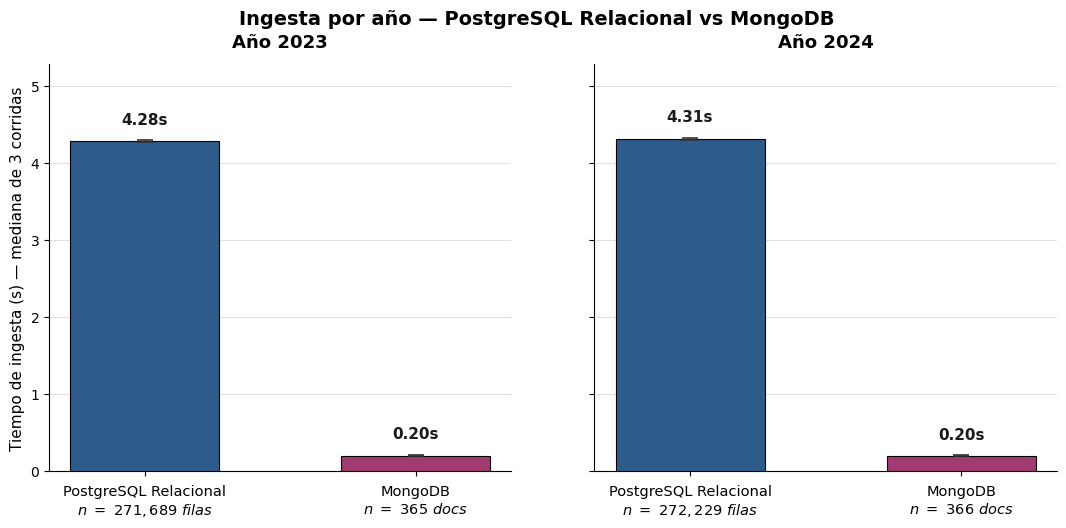

Figuras guardadas en parte2/


In [7]:
# ============================================================
# Gráficas tuneadas — estilo académico
# Lee de variables en memoria (tiempos_*, n_sql_*, etc.)
# Sobreescribe parte2/ingesta_global.png y parte2/ingesta_por_anio.png
# ============================================================
import matplotlib.pyplot as plt
import matplotlib as mpl

PALETA = {
    'PostgreSQL Relacional': '#2E5C8A',
    'MongoDB':               '#A23B72',
    'BigQuery':              '#E8833A',
    'Neo4j':                 '#3D7068',
    'PostgreSQL JSONB':      '#6B4E8F',
}

mpl.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'grid.color':        '#E0E0E0',
    'grid.linewidth':    0.8,
    'axes.axisbelow':    True,
    'xtick.labelsize':   10.5,
    'ytick.labelsize':   10,
    'figure.dpi':        100,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

def _pack(tiempos, n, unidad):
    """Devuelve dict con métricas listas para graficar."""
    med = statistics.median(tiempos)
    return {
        'mediana': med,
        'min':     min(tiempos),
        'max':     max(tiempos),
        'err_lo':  med - min(tiempos),
        'err_hi':  max(tiempos) - med,
        'n':       n,
        'unidad':  unidad,
    }

# Datos derivados de variables en memoria
sql_g   = _pack(tiempos_pg_global,    n_sql_global,         'filas')
mongo_g = _pack(tiempos_mongo_global, len(documentos_json), 'docs')
sql_23   = _pack(tiempos_pg_2023,    n_sql_2023,      'filas')
mongo_23 = _pack(tiempos_mongo_2023, len(docs_2023),  'docs')
sql_24   = _pack(tiempos_pg_2024,    n_sql_2024,      'filas')
mongo_24 = _pack(tiempos_mongo_2024, len(docs_2024),  'docs')

def _draw_bars(ax, motores, packs, titulo):
    ax.grid(axis='y', color='#E0E0E0', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    xs       = range(len(motores))
    valores  = [p['mediana'] for p in packs]
    errs_low = [p['err_lo']  for p in packs]
    errs_hi  = [p['err_hi']  for p in packs]
    colores  = [PALETA[m]    for m in motores]

    bars = ax.bar(xs, valores, color=colores, edgecolor='black',
                  linewidth=0.8, width=0.55, zorder=3)
    ax.errorbar(xs, valores, yerr=[errs_low, errs_hi], fmt='none',
                ecolor='#333333', capsize=6, capthick=1.2,
                elinewidth=1.2, zorder=4)

    ymax = max(v + eh for v, eh in zip(valores, errs_hi))
    offset = ymax * 0.04
    for x, v, eh in zip(xs, valores, errs_hi):
        ax.text(x, v + eh + offset, f'{v:.2f}s',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#1a1a1a', zorder=5)

    ax.set_xticks(list(xs))
    labels = [f"{m}\n$\\it{{n\\ =\\ {p['n']:,}\\ {p['unidad']}}}$"
              for m, p in zip(motores, packs)]
    ax.set_xticklabels(labels, fontsize=10.5)
    ax.set_ylabel('Tiempo de ingesta (s) — mediana de 3 corridas')
    ax.set_ylim(0, ymax * 1.22)
    ax.set_title(titulo, pad=12)
    ax.tick_params(axis='x', pad=6)

# ----- Figura 1: global -----
motores = ['PostgreSQL Relacional', 'MongoDB']
fig, ax = plt.subplots(figsize=(8.5, 5.5))
_draw_bars(ax, motores, [sql_g, mongo_g],
           'Ingesta global — PostgreSQL Relacional vs MongoDB')
fig.text(0.5, 0.005,
         f"Mismo universo · 731 días (2023–2024) · "
         f"SQL es {sql_g['mediana']/mongo_g['mediana']:.1f}× más lento por enforcement de FK en 13 tablas",
         ha='center', fontsize=9.5, style='italic', color='#444444')
plt.subplots_adjust(bottom=0.18)
fig.savefig(f'{OUTDIR}/ingesta_global.png')
plt.show()

# ----- Figura 2: por año -----
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
fig.suptitle('Ingesta por año — PostgreSQL Relacional vs MongoDB',
             fontsize=14, fontweight='bold', y=1.00)
_draw_bars(axes[0], motores, [sql_23, mongo_23], 'Año 2023')
_draw_bars(axes[1], motores, [sql_24, mongo_24], 'Año 2024')
axes[1].set_ylabel('')
plt.subplots_adjust(bottom=0.16, top=0.90, wspace=0.18)
fig.savefig(f'{OUTDIR}/ingesta_por_anio.png')
plt.show()

print('Figuras guardadas en', OUTDIR + '/')

## 6. Análisis

### Qué se está midiendo
- **PG Relacional:** 13 `INSERT ... VALUES` con `execute_values` y un único `commit`. El costo dominante es la verificación de PK/FK y la escritura de índices, sobre todo en `Boletos` (~263k filas) y `Pasajeros_Reserva` (~258k).
- **MongoDB:** un único `insert_many` de 731 documentos jerárquicos. Cada documento empaqueta vuelos + tripulación + boletos del día como árbol BSON. El costo es proporcional al **tamaño en bytes**, no al conteo de filas lógicas.

### Por qué los números no se leen "filas vs filas"
SQL inserta ~536k filas tabulares (12 tablas + tripulación). Mongo inserta 731 documentos que **contienen exactamente los mismos hechos** embebidos. La comparación honesta es: *tiempo de cargar el mismo universo en la forma natural de cada motor*. La tabla y las figuras lo declaran explícitamente.

### Trade-offs (más allá del tiempo de ingesta)
| Aspecto                | PG Relacional             | MongoDB                  |
|------------------------|---------------------------|--------------------------|
| Integridad referencial | Fuerte (FKs)              | A nivel aplicación       |
| Esquema                | Rígido                    | Flexible                 |
| Consultas analíticas   | SQL puro                  | Aggregation Framework    |
| Cambios de esquema     | DDL costoso               | Inmediato                |
| Sharding horizontal    | Manual (Citus)            | Nativo                   |

### Limitaciones del benchmark
1. Single-node, single-thread, todo en `localhost` (no mide red real).
2. SQL paga la indexación de claves primarias y foráneas en cada corrida; Mongo no construye índices secundarios.
3. No incluye `VACUUM ANALYZE` post-ingesta ni `createIndex` en Mongo.
4. La cache del sistema operativo entre corridas no se invalida (sólo se dropea la BD lógica).

### Decisiones que afectan PARTE 3 y PARTE 4
1. **P3 (BigQuery)** consume **el mismo `aeropuerto_jerarquico.json`** que Mongo. Granularidad = 731 docs RECORD/REPEATED. **No reaplanar.**
2. **P3** los timestamps son strings ISO sin TZ; BigQuery los acepta como `TIMESTAMP` nativo si se declara el schema correctamente, o como `STRING` si no.
3. **P4 (Neo4j)** usa el universo relacional completo (4,376 vuelos + 263k boletos + 9,978 tripulación). Esta PARTE 2 ya validó que la tripulación está poblada y disponible.
4. **Protocolo estándar para P3 y P4**: 3 corridas, mediana, reset entre corridas, `time.perf_counter()` sólo alrededor de la operación medida.

In [8]:
# ============================================================
# Export a parte2/ — artefactos para reporte final
# ============================================================

# --- metricas_parte2.csv ---
rows_csv = []
for motor, alcance, tiempos, n, unidad in [
    ('PostgreSQL Relacional', 'global', tiempos_pg_global,    n_sql_global,         'filas'),
    ('MongoDB',               'global', tiempos_mongo_global, len(documentos_json), 'docs'),
    ('PostgreSQL Relacional', '2023',   tiempos_pg_2023,      n_sql_2023,           'filas'),
    ('MongoDB',               '2023',   tiempos_mongo_2023,   len(docs_2023),       'docs'),
    ('PostgreSQL Relacional', '2024',   tiempos_pg_2024,      n_sql_2024,           'filas'),
    ('MongoDB',               '2024',   tiempos_mongo_2024,   len(docs_2024),       'docs'),
]:
    rows_csv.append({
        'motor': motor, 'alcance': alcance, 'unidad': unidad, 'n_unidades': n,
        'run1_s': round(tiempos[0], 4),
        'run2_s': round(tiempos[1], 4),
        'run3_s': round(tiempos[2], 4),
        'mediana_s': round(statistics.median(tiempos), 4),
        'min_s': round(min(tiempos), 4),
        'max_s': round(max(tiempos), 4),
    })

pd.DataFrame(rows_csv).to_csv(f'{OUTDIR}/metricas_parte2.csv', index=False)

# --- resumen_parte2.md ---
med_pg_g  = statistics.median(tiempos_pg_global)
med_mg_g  = statistics.median(tiempos_mongo_global)
med_pg_23 = statistics.median(tiempos_pg_2023)
med_mg_23 = statistics.median(tiempos_mongo_2023)
med_pg_24 = statistics.median(tiempos_pg_2024)
med_mg_24 = statistics.median(tiempos_mongo_2024)

resumen_md = f'''# Resumen PARTE 2 — Benchmark de Ingesta

## Comparativa: PostgreSQL Relacional vs MongoDB

Mismo universo PARTE 1 (731 días, 4,376 vuelos, 263,008 boletos, 9,978 tripulación), cada motor en su forma natural.

| Alcance | PG Relacional (mediana) | MongoDB (mediana) | n SQL (filas) | n Mongo (docs) |
|---|---:|---:|---:|---:|
| Global  | {med_pg_g:.3f} s  | {med_mg_g:.3f} s  | {n_sql_global:,} | {len(documentos_json):,} |
| 2023    | {med_pg_23:.3f} s | {med_mg_23:.3f} s | {n_sql_2023:,}   | {len(docs_2023):,} |
| 2024    | {med_pg_24:.3f} s | {med_mg_24:.3f} s | {n_sql_2024:,}   | {len(docs_2024):,} |

Protocolo: 3 corridas por motor por alcance, mediana reportada, `time.perf_counter()` solo alrededor de `execute_values+commit` (SQL) e `insert_many` (Mongo), reset de BD entre corridas.

## Decisión de granularidad
- SQL inserta filas normalizadas (su forma natural: 13 tablas).
- Mongo inserta los 731 documentos jerárquicos (su forma natural: árboles BSON).
- **No se aplana** el JSON a 263k docs planos. Esto preserva el modelo embebido de Mongo y mantiene paridad con P3 (BigQuery RECORD/REPEATED) y P4 (Neo4j).

## Decisiones que afectan P3 y P4
1. **P3 (BigQuery):** usar el mismo `aeropuerto_jerarquico.json` que Mongo. Granularidad = 731 docs anidados. **No re-aplanar.**
2. **P3:** los timestamps ISO sin TZ del JSON deben ingerirse tal cual (causa raíz del bug original mencionado en PARTE 1).
3. **P4 (Neo4j):** la tripulación está poblada (9,978 filas) y forma parte del benchmark SQL aquí. P4 puede usar el traversal Empleado→Tripulacion_Vuelo→Vuelo→Aerolinea para profundidad extra vs SQL.
4. **Protocolo de medición estándar (P3 y P4):** 3 corridas + mediana + reset de BD entre corridas + cronómetro solo alrededor de la operación medida.

## Artefactos exportados a `parte2/`
- `metricas_parte2.csv` — 3 corridas + mediana por motor por alcance.
- `ingesta_global.png` — comparativa global SQL vs Mongo.
- `ingesta_por_anio.png` — comparativa partida 2023 vs 2024.
- `resumen_parte2.md` — este archivo.
'''

with open(f'{OUTDIR}/resumen_parte2.md', 'w', encoding='utf-8') as f:
    f.write(resumen_md)

print('Exportado a', OUTDIR + '/')
for fn in sorted(os.listdir(OUTDIR)):
    print(' -', fn)

Exportado a parte2/
 - ingesta_global.png
 - ingesta_por_anio.png
 - metricas_parte2.csv
 - resumen_parte2.md
